# Illustrate generation of synthetic agglomerate structures

The idea is to have a very simple generator to create sufficient playground for method testing

In [1]:
import meatballsss as mbs
import numpy as np

Create meatball object which handles the grain map and orientations

Empty initialization will prompt a warning

In [2]:
agglomerate = mbs.VoxelizedMeatball()

/mnt/c/Users/sdaubner/workspace/meatballsss/meatballsss/fields.py:89: UserWarning: Empty initialization. Please generate a grain structure!
  warnings.warn("Empty initialization. Please generate a grain structure!")


Lets continue by generating a randomized structure. The function input is radius in voxels (30) and the amount of seed points (100). The particle will be padded with 5 voxels of electrolyte on each side.

In [3]:
agglomerate.create_random_agglomerate(30, 100)

The plot_slice function can be used to visualize grain structures or other associated fields in the agglomerate object. Just give the name of the field ('grains' is the default for the grain map) and the slice you would like to see. The slicing direction ('x', 'y', 'z') and colormap are optional.

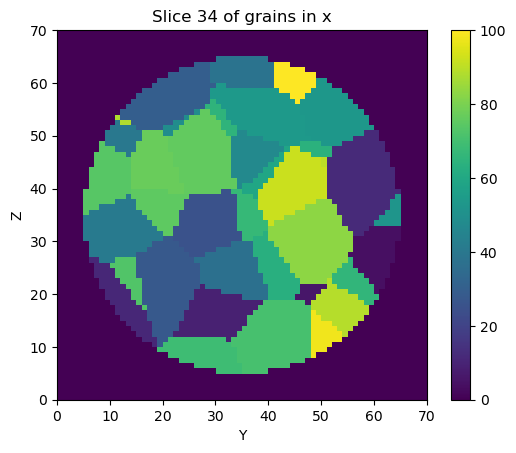

In [5]:
%matplotlib inline
agglomerate.plot_slice('grains', 34, direction='x', colormap='viridis')

There is also interactive plotting to go through the slices

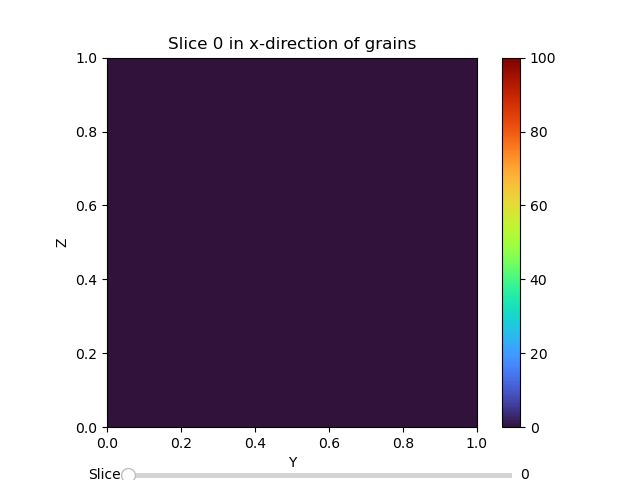

In [6]:
%matplotlib widget
agglomerate.plot_field_interactive("grains", direction='x', colormap='turbo')

### Structured agglomerate

Next is a structured agglomerate with a core-shell structure. Give as many radii as you want layers to appear.
 - radii = [10] --> particle with radius 10, all grains randomly aligned
 - radii = [20,50] --> inner core with radius 20 and randomly aligned grains, one shell with radius 50 and aligned grains
 - radii = [10,30,50] --> two shells of aligned grains and so on

In [7]:
radii = [20,50] # [20,50] #[50,80,110] #[30, 80, 100]
seed_nums = [50,100] # [50,100] #[100,150,400] #[50,300,50]

agglomerate.create_structured_agglomerate(radii, seed_nums)

/mnt/c/Users/sdaubner/workspace/meatballsss/meatballsss/fields.py:93: UserWarning: Previous grain map will be over-written!
  warnings.warn("Previous grain map will be over-written!")


Explore some more comfort features of the meatball object

In [8]:
colormap = agglomerate.generate_color_map()
print(colormap.shape)
print(colormap[55,55,55])
print(np.max(colormap[:,:,:,0]))


Generating colormap from grain_map and angle_list.
(110, 110, 110, 3)
[0.14238026 0.38017254 0.68001562]
0.9903349211591417


In [9]:
agglomerate.angles

array([[134.69234813, 152.87451764, 105.1558929 ],
       [ 49.76377617,  76.73450563,  72.63817747],
       [ 94.69838011,  72.51674958,  69.16826726],
       [163.56827108,  30.09346935,  58.71013937],
       [165.02742269,  93.13974989,  47.29878742],
       [  9.13886491,  48.89256586,  80.11123027],
       [ 16.40944227,  71.17641178,  44.93886967],
       [ 72.30756627,  98.22468499,  36.71394695],
       [ 78.61525407, 158.85727074,  13.92902743],
       [ 35.23920675,  24.95576954,  55.15152466],
       [ 32.34439491, 102.84928049,  16.73314665],
       [ 57.59793209, 144.72793416,  47.30599729],
       [ 45.97586298,  34.77525209,  83.7107869 ],
       [128.73866563, 119.74784617,  63.16030778],
       [103.57834833, 112.70826987,  74.41910819],
       [161.40154276, 127.92491118,  33.71161728],
       [ 85.53290314, 109.60946886,   4.52216587],
       [127.2146449 , 157.64167853,  78.04243775],
       [109.75772764, 162.39299332,  80.62935237],
       [ 43.09425388, 152.82855

In [10]:
agglomerate.export_fields_to_vtk()

In [11]:
agglomerate.export_orientations_to_vtk()

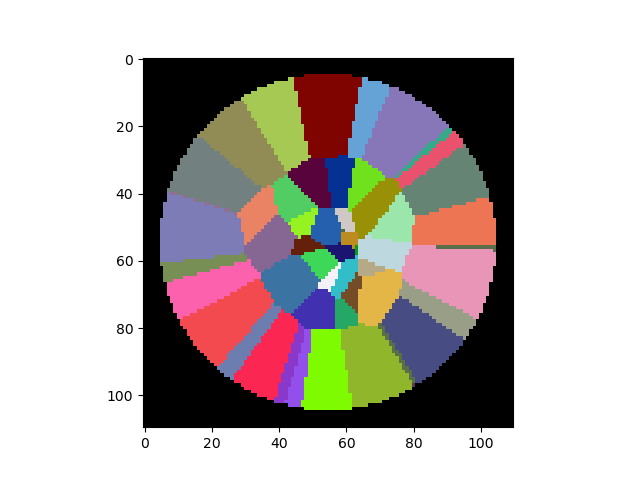

In [12]:
import matplotlib.pyplot as plt
plt.figure()
im = plt.imshow(colormap[55,:,:])

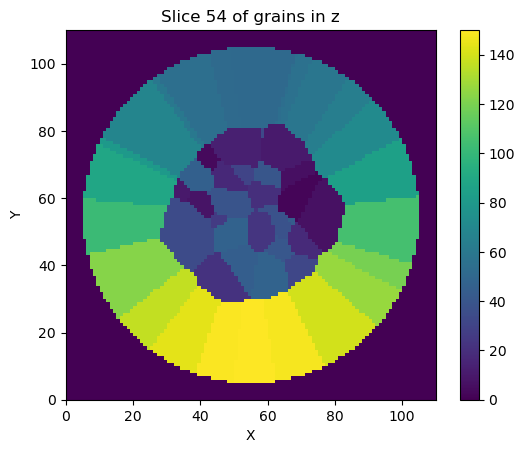

In [14]:
%matplotlib inline
agglomerate.plot_slice('grains', 54)

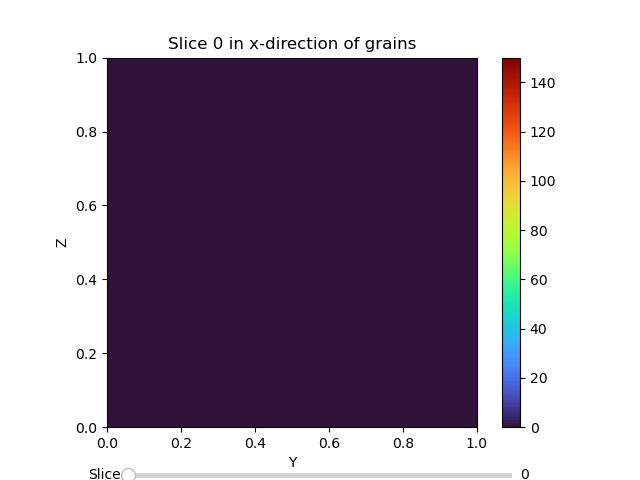

In [7]:
%matplotlib widget
agglomerate.plot_field_interactive("grains", direction='x', colormap='turbo')

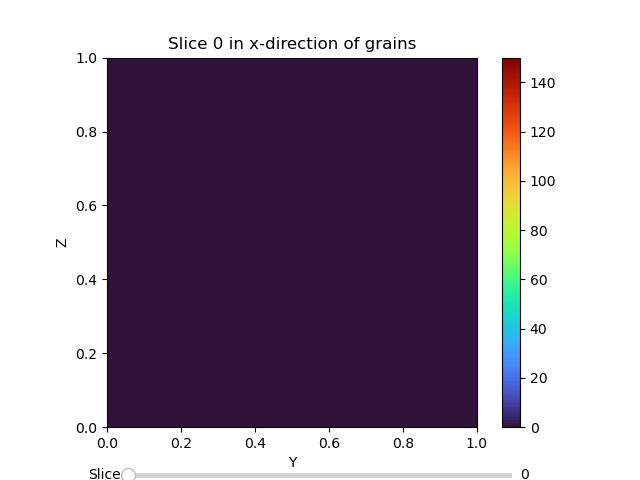

In [12]:
agglomerate.relabel_random_order()
%matplotlib widget
agglomerate.plot_field_interactive("grains", direction='x', colormap='turbo')

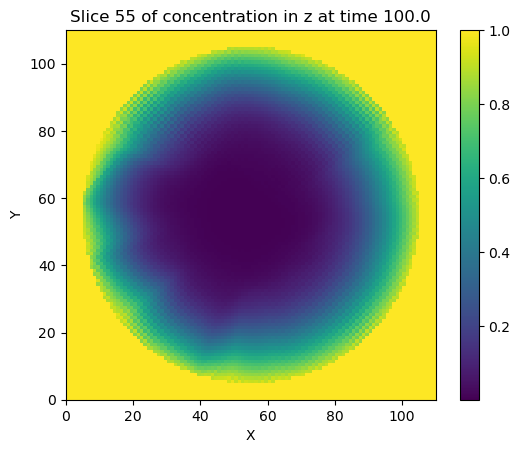

Wall time: 44.3795 s (0.0044 s/iter)
GPU-RAM currently allocated 69.15 MB (127.93 MB reserved)
GPU-RAM maximally allocated 85.16 MB (127.93 MB reserved)


In [13]:
%matplotlib inline
sim = mbs.PITTSolver(agglomerate, diffusivity=[1,1,0.1])
sim.solve(time_increment=0.01, max_iters=10000, frames=20, verbose='plot')

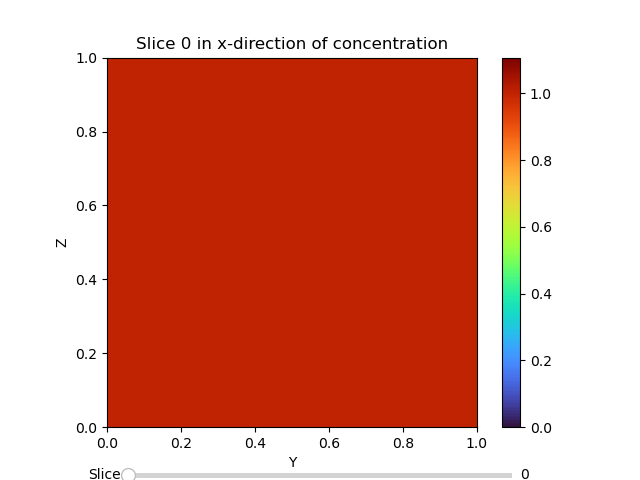

In [14]:
%matplotlib widget
agglomerate.plot_field_interactive("concentration", direction='x', colormap='turbo')